<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 128 · Time Series & Forecasting</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Forecasting Models</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Fit the standard forecasting toolkit, baselines, moving averages, Holt-Winters exponential smoothing, and ARIMA/SARIMA, on ten years of airport passengers; hold out the last year, compare with MAPE, and see the difference between a static one-step forecast and an honest multi-step one.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Forecasting Models
Chapter 127 pulled a series apart; this one predicts its future. We fit the standard forecasting toolkit, **baselines**, **moving averages and exponential smoothing (Holt-Winters)**, and **ARIMA/SARIMA**, on ten years of monthly airport passengers, hold out the last year, and see which model actually forecasts it best. Everything runs on **statsmodels**, and the golden rule is the same throughout: split in time and always beat a baseline.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings('ignore')
def mape(actual, forecast): return float(np.mean(np.abs((actual.values - np.asarray(forecast)) / actual.values)) * 100)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">REAL DATA &#183; TEN YEARS OF PASSENGERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A growing regional airport</div>
<div style="color:#4a5578;margin-top:6px">120 monthly points; hold out the last 12.</div>
</div>

train: 108 months  |  test: 12 months (the most recent year)


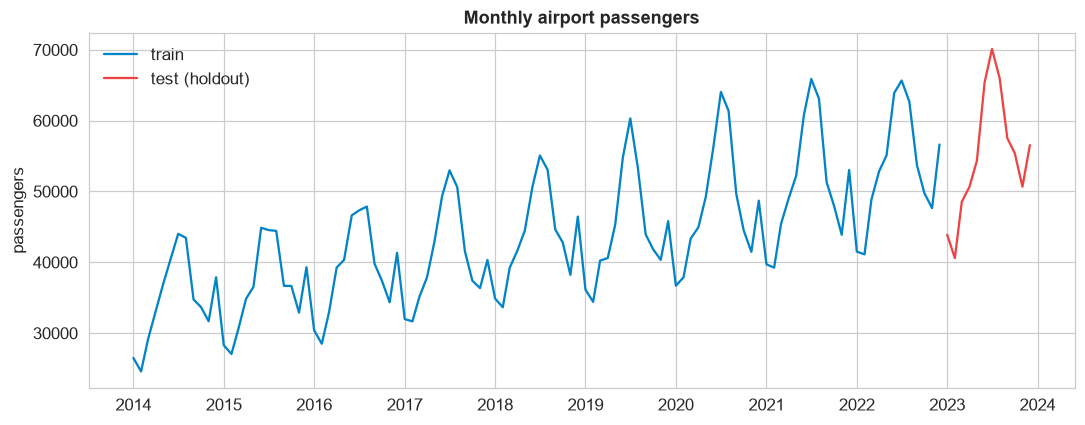

In [3]:
try: raw = pd.read_excel('../../data/forecasting-models--airport_passengers.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'forecasting-models--airport_passengers.xlsx', sheet_name='Data')
raw['month']=pd.to_datetime(raw['month']); s = raw.set_index('month')['passengers'].asfreq('MS')
train, test = s[:-12], s[-12:]     # CHRONOLOGICAL split: never shuffle a time series
print('train:', len(train), 'months  |  test:', len(test), 'months (the most recent year)')
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(train.index, train, color=EM, label='train'); ax.plot(test.index, test, color=RED, label='test (holdout)')
ax.set(title='Monthly airport passengers', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()

Two rules before any model. First, **split in time**, train on the past, test on the most recent stretch; shuffling would let the model peek at the future. Second, we judge forecasts with **MAPE** (mean absolute percentage error), so errors are comparable across scales. Now, the ladder of models.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 1 &#183; BASELINES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The bar every model must clear</div>
<div style="color:#4a5578;margin-top:6px">If you cannot beat the naive forecast, stop.</div>
</div>

naive (last value)   MAPE: 13.63%
seasonal-naive       MAPE: 4.13%  <- the real bar to clear


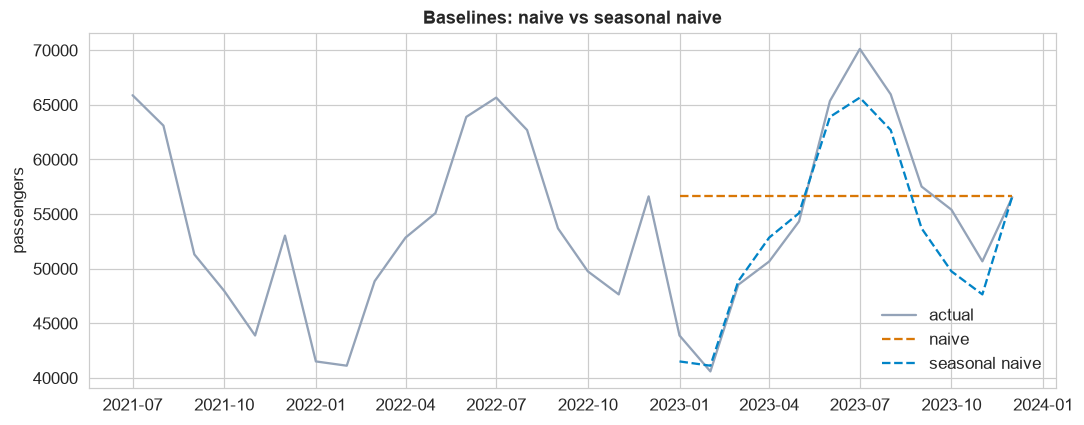

In [4]:
naive = np.repeat(train.iloc[-1], 12)                 # tomorrow = today
snaive = train.iloc[-12:].values                      # this month = same month last year
print('naive (last value)   MAPE: %.2f%%' % mape(test, naive))
print('seasonal-naive       MAPE: %.2f%%  <- the real bar to clear' % mape(test, snaive))
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(s.index[-30:], s.values[-30:], color=GREY, label='actual')
ax.plot(test.index, naive, '--', color=AMBER, label='naive'); ax.plot(test.index, snaive, '--', color=EM, label='seasonal naive')
ax.set(title='Baselines: naive vs seasonal naive', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()

A forecast is only impressive relative to the obvious. The **naive** forecast (repeat the last value) ignores the yearly wave and lands at a poor **13.6% MAPE**. The **seasonal-naive** forecast (repeat the value from 12 months ago) captures the seasonality for free and cuts that to **4.1%**. That 4.1% is the number every real model must beat.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 2 &#183; MOVING AVERAGE &amp; SIMPLE SMOOTHING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Average the recent past</div>
<div style="color:#4a5578;margin-top:6px">Good smoothers, weak forecasters on their own.</div>
</div>

simple exponential smoothing: alpha = 1.00
SES MAPE: 13.63%  (no trend, no season -> forecasts a flat line, as bad as naive)


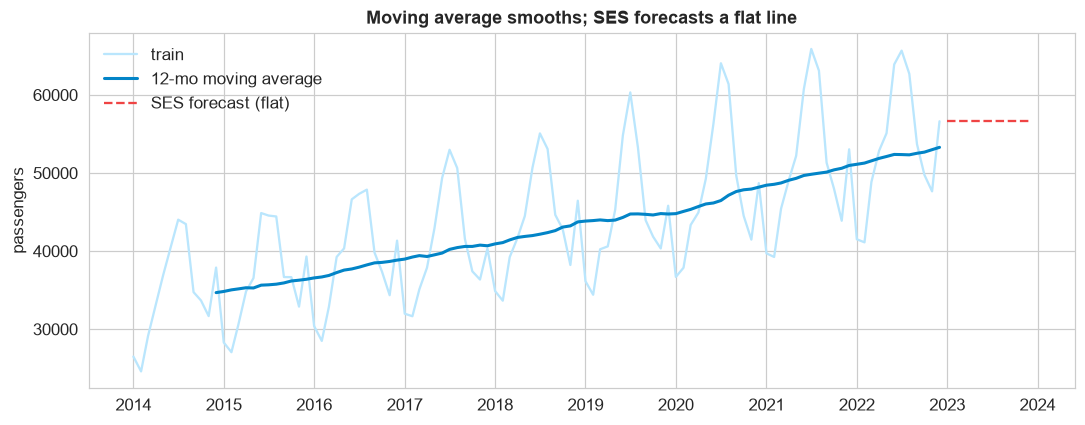

In [5]:
ma = train.rolling(12).mean()
ses = SimpleExpSmoothing(train).fit()
print('simple exponential smoothing: alpha = %.2f' % ses.params['smoothing_level'])
print('SES MAPE: %.2f%%  (no trend, no season -> forecasts a flat line, as bad as naive)' % mape(test, ses.forecast(12)))
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(train.index, train, color=LIGHT, label='train'); ax.plot(ma.index, ma, color=EM, lw=2, label='12-mo moving average')
ax.plot(test.index, ses.forecast(12), '--', color=RED, label='SES forecast (flat)'); ax.set(title='Moving average smooths; SES forecasts a flat line', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()

A **moving average** smooths the series but does not extrapolate. **Simple exponential smoothing (SES)** forecasts a weighted average of the past, with weights that fade geometrically (controlled by a single rate, alpha). It is a fine level-tracker, but with no trend or seasonal term it predicts a **flat line** and here scores a weak 13.6%. SES is the base of a family whose other members add the missing pieces.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 3 &#183; HOLT-WINTERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Add trend and seasonality</div>
<div style="color:#4a5578;margin-top:6px">Exponential smoothing, completed.</div>
</div>

Holt-Winters additive       MAPE: 3.37%
Holt-Winters multiplicative MAPE: 2.83%  <- matches the growing swing


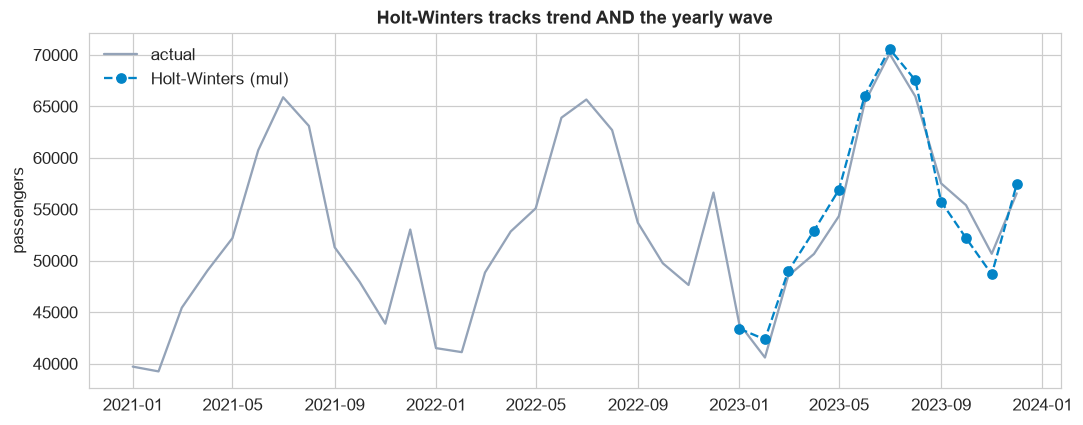

In [6]:
hw_add = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
hw_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12).fit()
print('Holt-Winters additive       MAPE: %.2f%%' % mape(test, hw_add.forecast(12)))
print('Holt-Winters multiplicative MAPE: %.2f%%  <- matches the growing swing' % mape(test, hw_mul.forecast(12)))
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(s.index[-36:], s.values[-36:], color=GREY, label='actual')
ax.plot(test.index, hw_mul.forecast(12), 'o--', color=EM, label='Holt-Winters (mul)')
ax.set(title='Holt-Winters tracks trend AND the yearly wave', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()

**Holt-Winters** extends smoothing with three updating parts, **level**, **trend**, and **season**, each with its own smoothing rate. Because this series' seasonal swing grows with the level, the **multiplicative** version fits best, dropping the error to **2.8% MAPE**, comfortably beating the seasonal-naive baseline. Matching the model's seasonal type (additive vs multiplicative) to the data is exactly the choice from Chapter 127.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 4 &#183; ARIMA &amp; SARIMA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Model the correlations directly</div>
<div style="color:#4a5578;margin-top:6px">AR + differencing + MA, with a seasonal copy.</div>
</div>

**ARIMA(p,d,q)** combines three ideas: **AR(p)** regresses on recent *values*, **I(d)** *differences* the series d times to make it stationary (the exact step from Chapter 127), and **MA(q)** regresses on recent *errors*. **SARIMA(p,d,q)(P,D,Q)s** bolts on a seasonal copy of all three at lag s. Here s = 12.

SARIMA(1,1,1)(1,1,1,12)  AIC 1436  MAPE 3.74%


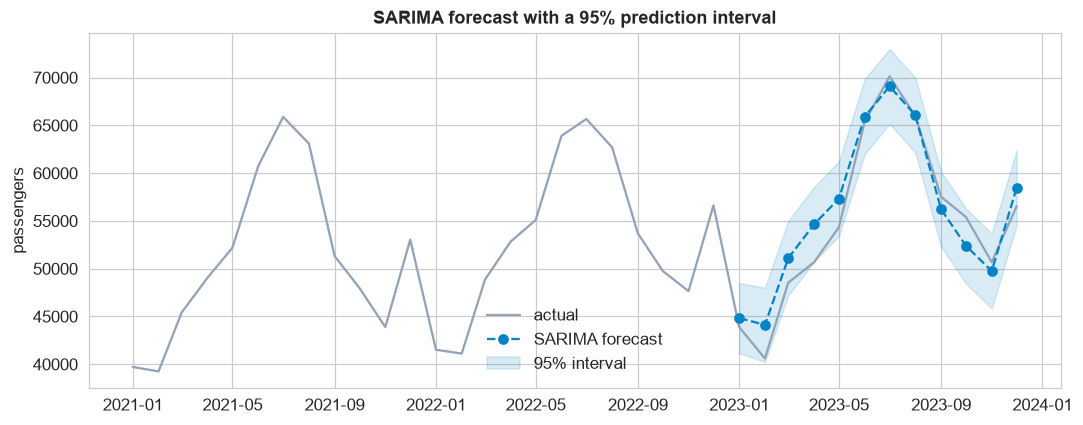

In [7]:
sar = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = sar.get_forecast(12); mean = fc.predicted_mean; ci = fc.conf_int()
print('SARIMA(1,1,1)(1,1,1,12)  AIC %.0f  MAPE %.2f%%' % (sar.aic, mape(test, mean)))
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(s.index[-36:], s.values[-36:], color=GREY, label='actual')
ax.plot(mean.index, mean, 'o--', color=EM, label='SARIMA forecast')
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color=EM, alpha=0.15, label='95% interval')
ax.set(title='SARIMA forecast with a 95% prediction interval', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()

SARIMA forecasts the holdout at **3.7% MAPE**, also beating the baseline, and, unlike Holt-Winters, it hands you a **prediction interval** for free (the shaded band), because it is a full statistical model. The `d=1` and `D=1` orders are just the first and seasonal differences that made the series stationary last chapter. Holt-Winters or SARIMA is often a coin toss; fit both and let the holdout decide.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 5 &#183; STATIC vs DYNAMIC FORECASTING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One step ahead, or many</div>
<div style="color:#4a5578;margin-top:6px">How far into the future is each prediction?</div>
</div>

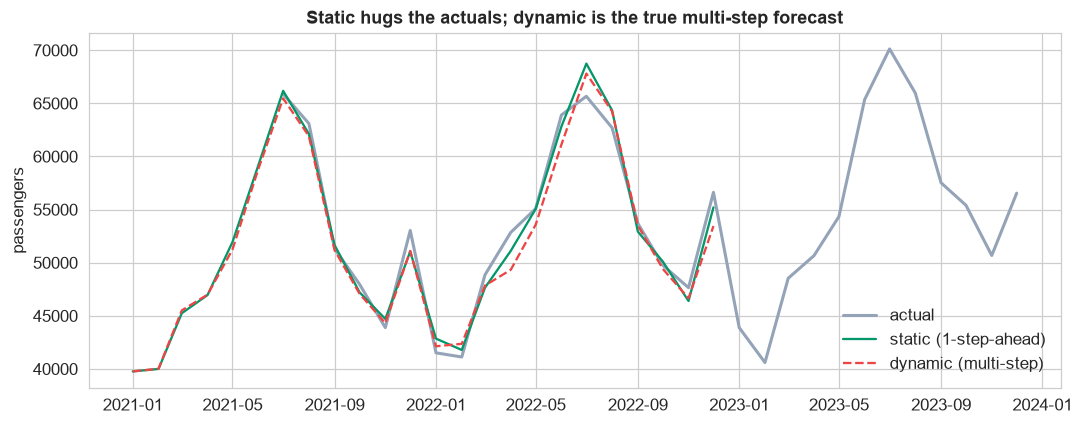

static = evaluate one step ahead using real history (optimistic).
dynamic = recursively feed predictions forward (honest multi-step, what you get in production).


In [8]:
pred_static  = sar.get_prediction(start=-24, dynamic=False)   # each step uses the ACTUAL recent values
pred_dynamic = sar.get_prediction(start=-24, dynamic=True)    # feeds its OWN predictions forward
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(s.index[-30:], s.values[-30:], color=GREY, lw=2, label='actual')
ax.plot(pred_static.predicted_mean.index, pred_static.predicted_mean, color=GREEN, label='static (1-step-ahead)')
ax.plot(pred_dynamic.predicted_mean.index, pred_dynamic.predicted_mean, '--', color=RED, label='dynamic (multi-step)')
ax.set(title='Static hugs the actuals; dynamic is the true multi-step forecast', ylabel='passengers'); ax.legend(); plt.tight_layout(); plt.show()
print('static = evaluate one step ahead using real history (optimistic).')
print('dynamic = recursively feed predictions forward (honest multi-step, what you get in production).')

A **static** (one-step-ahead) forecast uses the *actual* past value at every step, so it hugs the data and looks great, but it answers &#8220;how good is next month?&#8221; only. A **dynamic** (multi-step) forecast feeds its **own predictions** back in and rolls forward, which is what you truly face when forecasting a year out. Dynamic error is always larger and grows with the horizon; report the one that matches your decision. Judging a static forecast and then deploying it for 12-month planning is a classic way to over-promise.

## The forecasting toolkit, in one view

1. **Split in time and set a baseline** (seasonal-naive here at 4.1% MAPE); never shuffle, always beat the baseline.
2. **Moving average / SES** smooth the level but forecast flat, use them as a floor, not a finish.
3. **Holt-Winters (ETS)** adds trend and seasonality; match additive vs multiplicative to the data (best here, 2.8%).
4. **ARIMA / SARIMA** model the autocorrelations after differencing and give prediction intervals (3.7% here).
5. **Static vs dynamic**: one-step-ahead flatters the model; multi-step is the honest test, report the one that fits the decision.

**The one idea to keep: there is no single best forecaster, there is the model whose structure matches your data's trend and seasonality and that beats a seasonal-naive baseline on a held-out, multi-step test.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>